<a href="https://colab.research.google.com/github/Donthula-Harika/Deep-Learning/blob/main/CNN/CNN_fashion_mnidst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🛍 Scenario: Fashion Product Image Classifier
# You are working as an AI Engineer for an e-commerce company.
# The company wants to automatically classify clothing products from images into categories such as:
# T-shirt
# Trouser
# Pullover
# Dress
# Coat
# Sandal
# Shirt
# Sneaker
# Bag
# Ankle boot
# The dataset contains 28×28 grayscale images of fashion items.
# Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

# Task 1 — Dataset Exploration
# Load the Fashion-MNIST dataset and perform basic inspection.
# Students must:
# Load dataset using TensorFlow/Keras
# Print:
# Number of training images
# Number of testing images
# Display 10 random images with their labels
# Goal:

# Understand the dataset visually.



In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

Number of training images: 60000
Number of testing images: 10000


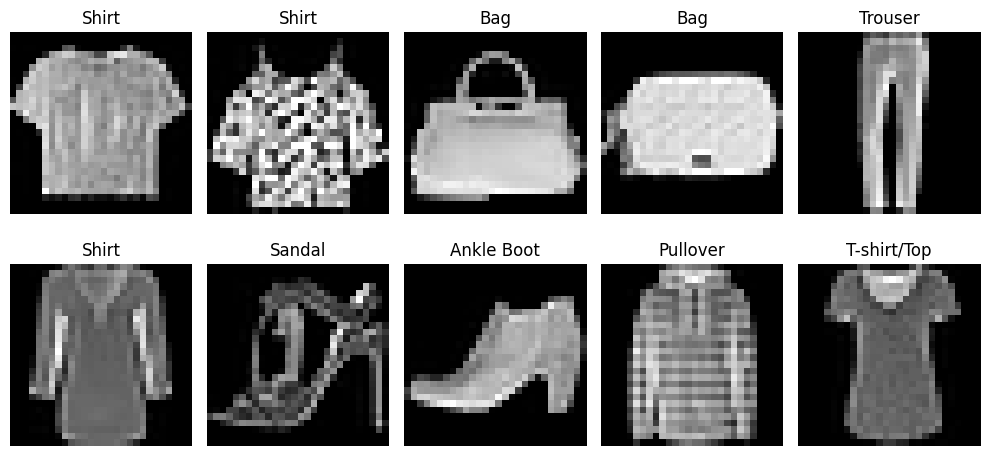

In [ ]:
(x_train , y_train) , (x_test , y_test) = fashion_mnist.load_data()

print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])

# Fashion MNIST labels
labels = ["T-shirt/Top","Trouser","Pullover","Dress","Coat",
          "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

# Display 10 random images
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, x_train.shape[0])

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(labels[y_train[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Task 2 — Data Preprocessing
# Prepare the dataset for CNN training.
# Students must:
# Normalize pixel values (0–255 → 0–1)
# Reshape images to CNN format
# Expected shape:
# (28, 28, 1)
# Also convert labels to one-hot encoding.

# Task 3 — Visualize Class Distribution
# Students must:
# Count number of images in each class
# Plot bar chart of class distribution
# Goal:

# Check whether the dataset is balanced.

In [ ]:
# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape images to CNN format (28,28,1)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print("New shape of training data:", x_train.shape)
print("New shape of testing data:", x_test.shape)

New shape of training data: (60000, 28, 28, 1)
New shape of testing data: (10000, 28, 28, 1)


In [ ]:
# Task 3 — Visualize Class Distribution
# Students must:
# Count number of images in each class
# Plot bar chart of class distribution
# Goal:
# Check whether the dataset is balanced.

New shape of training data: (60000, 28, 28, 1)
New shape of testing data: (10000, 28, 28, 1)


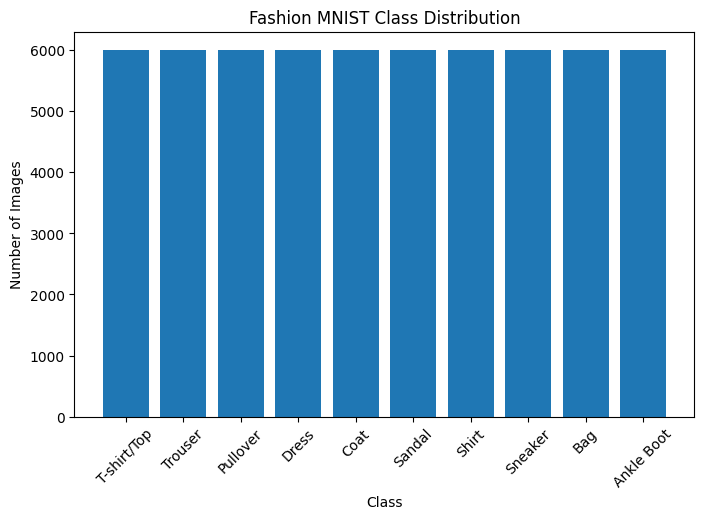

In [ ]:

print("New shape of training data:", x_train.shape)
print("New shape of testing data:", x_test.shape)


# -------------------------------
# Task 3 — Class Distribution
# -------------------------------

# Count images in each class
class_counts = np.sum(y_train, axis=0)

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(labels, class_counts)

plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Fashion MNIST Class Distribution")

plt.show()

In [ ]:
# Task 4 — Build First CNN Architecture
# Students must implement a CNN with this architecture:
# Input (28x28x1)
# ↓
# Conv2D (32 filters, 3x3)
# ↓
# ReLU
# ↓
# MaxPooling (2x2)
# ↓
# Conv2D (64 filters, 3x3)
# ↓
# ReLU
# ↓
# MaxPooling (2x2)
# ↓
# Flatten
# ↓
# Dense (128)
# ↓
# Softmax (10)
# Goal:
# Understand basic CNN architecture.

In [ ]:

model = Sequential()

# Input + Conv Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Second Conv Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Show model structure
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model
# Train the CNN with:
# Epochs = 10
# Batch size = 64
# Validation split = 20%
# Students must:
# Plot training accuracy vs validation accuracy
# Plot training loss vs validation loss
# Goal:
# Observe model learning behaviour.

In [ ]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)



Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7508 - loss: 0.7170 - val_accuracy: 0.8651 - val_loss: 0.3695
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8724 - loss: 0.3489 - val_accuracy: 0.8802 - val_loss: 0.3288
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8898 - loss: 0.2972 - val_accuracy: 0.8932 - val_loss: 0.2907
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9062 - loss: 0.2577 - val_accuracy: 0.9005 - val_loss: 0.2750
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9140 - loss: 0.2338 - val_accuracy: 0.9046 - val_loss: 0.2602
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9241 - loss: 0.2067 - val_accuracy: 0.9095 - val_loss: 0.2519
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9312 - loss: 0.1841 - val_accuracy: 0.9068 - val_loss: 0.2595
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9366 - loss: 0.1699 - val_accuracy: 0

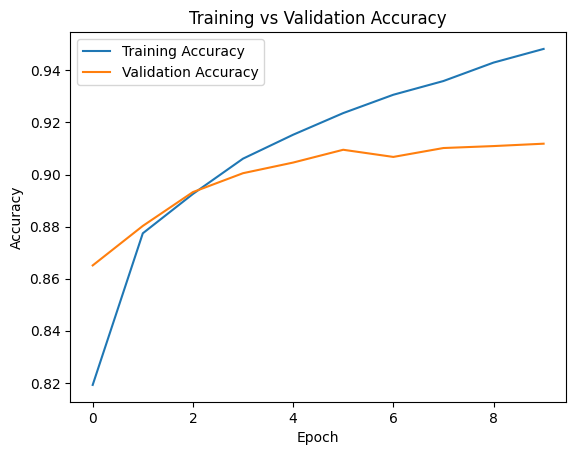

In [ ]:

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

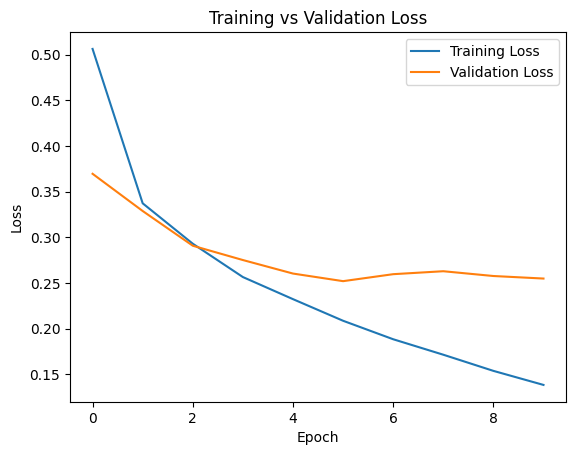

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9078 - loss: 0.2876
Test Loss: 0.2756904363632202
Test Accuracy: 0.9096999764442444
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step


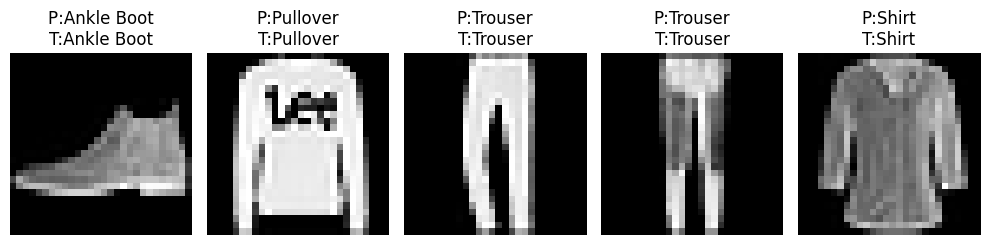

In [ ]:

# Evaluate on test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# Predict on first 5 test images
predictions = model.predict(x_test[:5])

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:5], axis=1)

labels = ["T-shirt/Top","Trouser","Pullover","Dress","Coat",
          "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

# Display images with predictions
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{labels[predicted_classes[i]]}\nT:{labels[true_classes[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step


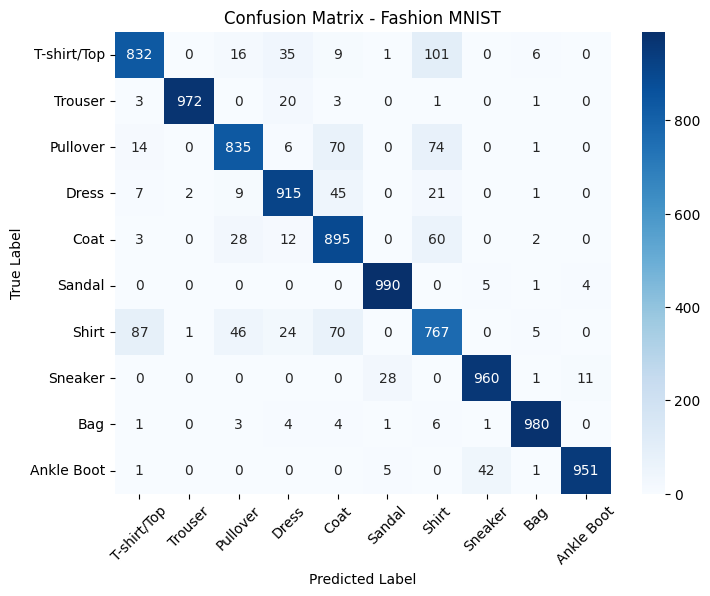

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -------------------------------
# Task 8 — Confusion Matrix Analysis
# -------------------------------

# Predict all test images
y_pred = model.predict(x_test)

# Convert one-hot back to class numbers
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

labels = ["T-shirt/Top","Trouser","Pullover","Dress","Coat",
          "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fashion MNIST")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [ ]:
# Task 9 — Improve the CNN Architecture
# Students must modify the architecture by:
# Adding Dropout layer
# Increasing filters
# Adding another convolution layer
# Example:
# Conv → Conv → Pool → Conv → Pool
# Then compare:
# Model 1 accuracy vs Model 2 accuracy
# Goal:

# Understand model improvement strategies.


In [ ]:
from keras.layers import Dropout

# -------------------------------
# Improved CNN Model (Model 2)
# -------------------------------

model2 = Sequential()

# First block
model2.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model2.add(Conv2D(32,(3,3),activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Second block
model2.add(Conv2D(64,(3,3),activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Flatten
model2.add(Flatten())

# Dropout to reduce overfitting
model2.add(Dropout(0.5))

# Dense layer
model2.add(Dense(128,activation='relu'))

# Output layer
model2.add(Dense(10,activation='softmax'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,282 (915.16 KB)

 Trainable params: 234,282 (915.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history2 = model2.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.7138 - loss: 0.7922 - val_accuracy: 0.8585 - val_loss: 0.3893
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8654 - loss: 0.3678 - val_accuracy: 0.8928 - val_loss: 0.2961
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8850 - loss: 0.3131 - val_accuracy: 0.9067 - val_loss: 0.2574
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8979 - loss: 0.2770 - val_accuracy: 0.9120 - val_loss: 0.2395
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9072 - loss: 0.2525 - val_accuracy: 0.9138 - val_loss: 0.2378
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9109 - loss: 0.2363 - val_accuracy: 0.9186 - val_loss: 0.2238
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9169 - loss: 0.2166 - val_accuracy: 0.9187 - val_loss: 0.2239
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9202 - loss: 0.2138 - val_accuracy: 

In [ ]:
test_loss2, test_accuracy2 = model2.evaluate(x_test,y_test)

print("Model 1 Test Accuracy:", test_accuracy)
print("Model 2 Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9181 - loss: 0.2294
Model 1 Test Accuracy: 0.9096999764442444
Model 2 Test Accuracy: 0.91839998960495


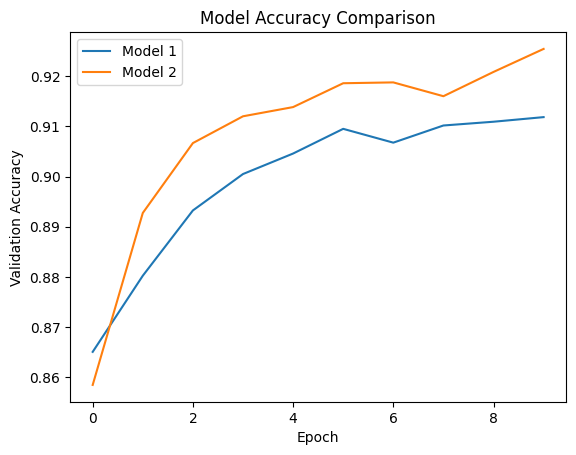

In [ ]:
plt.plot(history.history['val_accuracy'], label="Model 1")
plt.plot(history2.history['val_accuracy'], label="Model 2")

plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


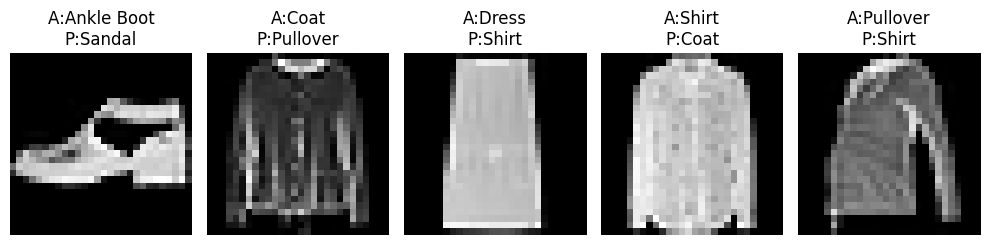

In [ ]:
# -------------------------------
# Task 10 — Misclassification Analysis
# -------------------------------

# Predict all test images
y_pred = model.predict(x_test)

# Convert predictions and labels
predicted_classes = np.argmax(y_pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Find wrongly predicted indexes
wrong_indexes = np.where(predicted_classes != true_classes)[0]

labels = ["T-shirt/Top","Trouser","Pullover","Dress","Coat",
          "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

# Display 5 wrongly predicted images
plt.figure(figsize=(10,4))

for i in range(5):
    index = wrong_indexes[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')
    plt.title(f"A:{labels[true_classes[index]]}\nP:{labels[predicted_classes[index]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step


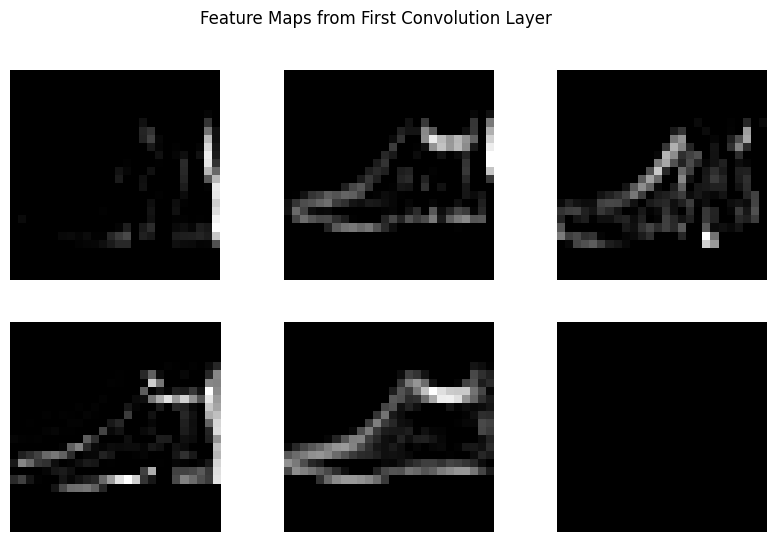

In [ ]:

from keras.models import Model

# Select one test image
img = x_test[0].reshape(1,28,28,1)

# Extract outputs of first few layers
layer_outputs = [layer.output for layer in model.layers[:4]]

# FIX: use model.inputs instead of model.input
feature_model = Model(inputs=model.inputs, outputs=layer_outputs)

# Get feature maps
feature_maps = feature_model.predict(img)

# Visualize feature maps
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0][0,:,:,i], cmap='gray')
    plt.axis("off")

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step


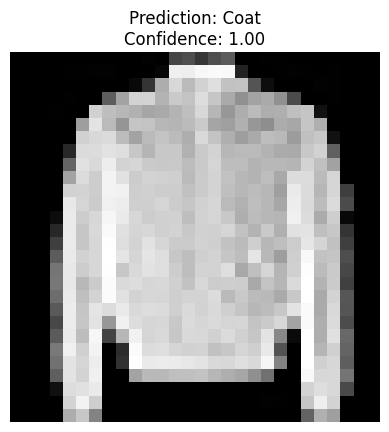

Predicted Class: Coat
Prediction Confidence: 0.9974443


In [ ]:
# -------------------------------
# Random Image Prediction
# -------------------------------

# Select random test image
index = np.random.randint(0, len(x_test))
image = x_test[index].reshape(1,28,28,1)

# Predict
prediction = model.predict(image)

predicted_class = np.argmax(prediction)
probability = np.max(prediction)

labels = ["T-shirt/Top","Trouser","Pullover","Dress","Coat",
          "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

# Display image
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Prediction: {labels[predicted_class]}\nConfidence: {probability:.2f}")
plt.axis("off")
plt.show()

print("Predicted Class:", labels[predicted_class])
print("Prediction Confidence:", probability)